In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cardiovascular dataset.csv", sep=';')

In [3]:
#What is the shape of the dataset?
df.shape

(70000, 13)

In [4]:
#Are there any missing values?
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [5]:
#Unique values for categorical features (gender, cholesterol, gluc)
df[['gender', 'cholesterol', 'gluc']].nunique()

gender         2
cholesterol    3
gluc           3
dtype: int64

In [6]:
df[['gender', 'cholesterol', 'gluc']].value_counts()

gender  cholesterol  gluc
1       1            1       31237
2       1            1       17435
1       2            1        4488
        3            1        2746
                     3        2455
2       2            1        2241
1       2            2        1667
        1            2        1393
2       3            1        1332
                     3        1017
1       1            3         940
2       1            2         842
        2            2         772
        1            3         538
1       3            2         356
        2            3         248
2       3            2         160
        2            3         133
Name: count, dtype: int64

In [7]:
#What is the average age of patients (in years)?
df['age_years'] = df['age'] / 365.25
df['age_years'].mean()

np.float64(53.3028495942114)

In [8]:
#Distribution of the target variable (cardio)
df['cardio'].value_counts(normalize=True)

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

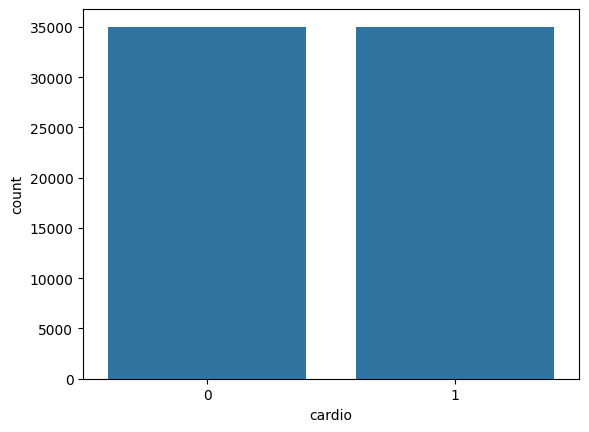

In [9]:
sns.countplot(x='cardio', data=df)
plt.show()

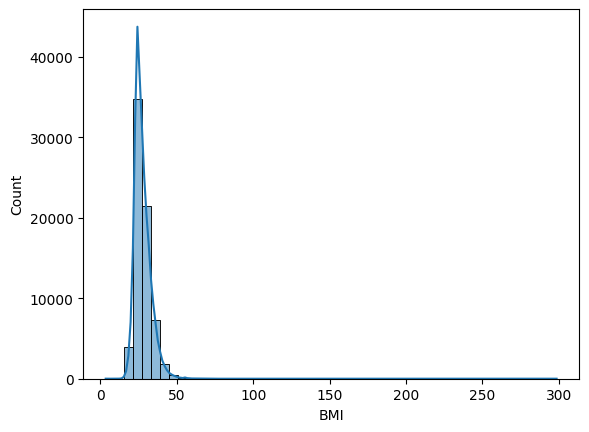

In [10]:
#Distribution of BMI (Create BMI feature)
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
sns.histplot(df['BMI'], bins=50, kde=True)
plt.show()

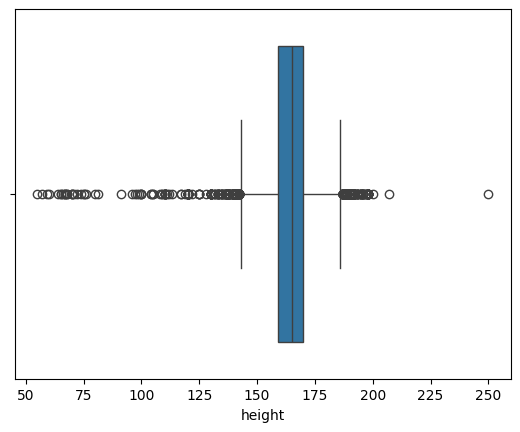

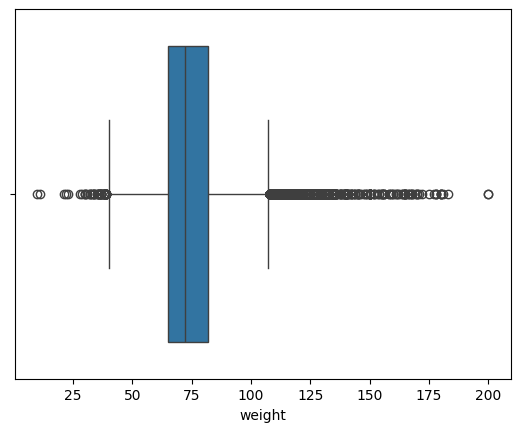

In [11]:
#Are there outliers in height or weight?
sns.boxplot(x=df['height'])
plt.show()

sns.boxplot(x=df['weight'])
plt.show()

In [12]:
#Implausible blood pressure values?
invalid_bp = df[
    (df['ap_hi'] < 80) | (df['ap_hi'] > 250) |
    (df['ap_lo'] < 50) | (df['ap_lo'] > 200) |
    (df['ap_hi'] < df['ap_lo'])
]

In [13]:
#How many rows have incorrect blood pressure values? 
#Column                Condition                      Reason 
#ap_hi                  between 80 and 250            realistic systolic
#ap_lo                 between 50 and 200             realistic diastolic
#ap_hi >= ap_lo       systolic must be ≥ diastolic   logical  
invalid_bp.shape[0]

1348

In [14]:
#Remove rows with invalid BP, height, or weight
df_clean = df[
    (df['ap_hi'].between(80, 250)) &
    (df['ap_lo'].between(50, 200)) &
    (df['ap_hi'] >= df['ap_lo']) &
    (df['height'].between(120, 220)) &
    (df['weight'].between(40, 200))
]
df_clean

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.676249,26.927438
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.878166,50.472681
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.199863,31.353579
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.412731,27.099251


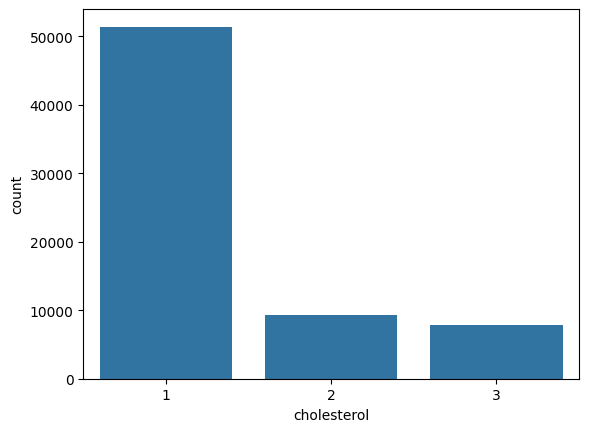

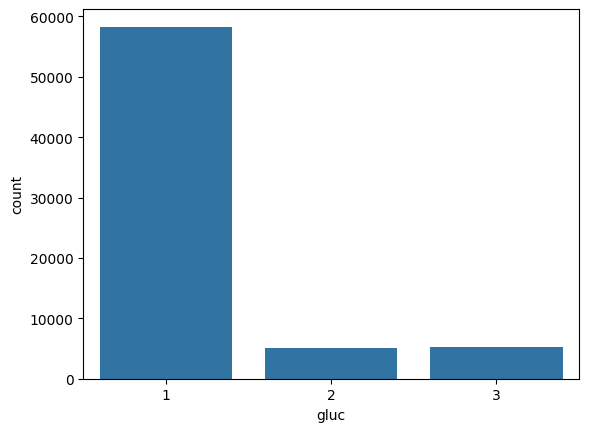

In [15]:
#Distribution of cholesterol & glucose after cleaning
sns.countplot(x='cholesterol', data=df_clean)
plt.show()

sns.countplot(x='gluc', data=df_clean)
plt.show()

In [16]:
#How many smokers have cardiovascular disease?
df_clean[(df_clean['smoke'] == 1) & (df_clean['cardio'] == 1)].shape[0]

2826

In [17]:
#Does alcohol intake correlate with higher cardio risk?
df_clean.groupby('alco')['cardio'].mean()

alco
0    0.495816
1    0.477037
Name: cardio, dtype: float64

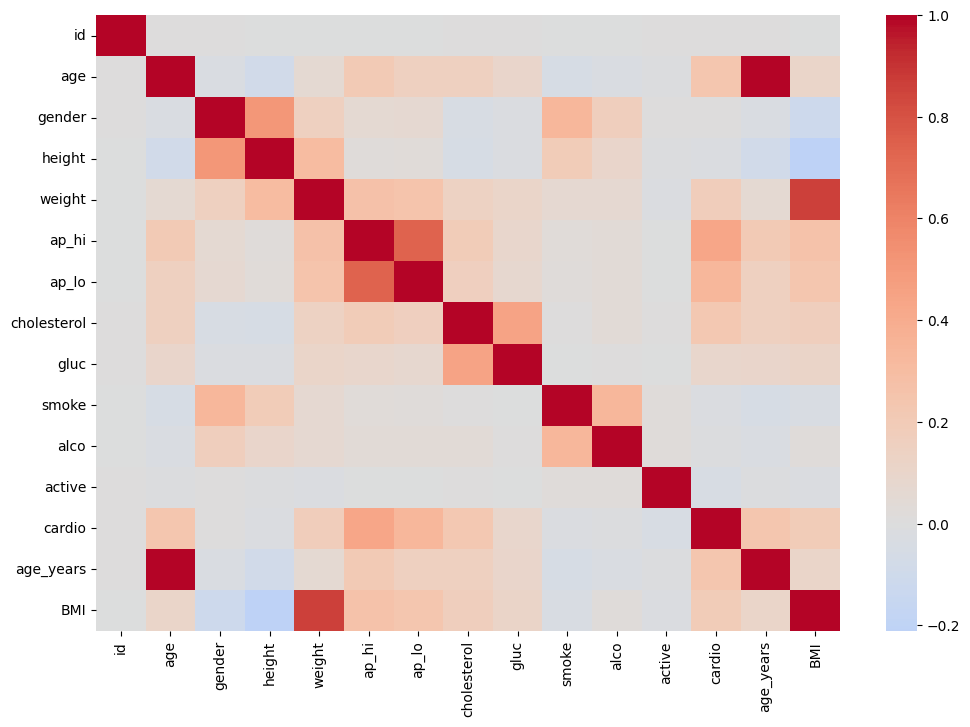

In [18]:
#Correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap='coolwarm', center=0)
plt.show()

In [19]:
#Mean BMI: cardio vs non-cardio
df_clean.groupby('cardio')['BMI'].mean()

cardio
0    26.480744
1    28.470066
Name: BMI, dtype: float64

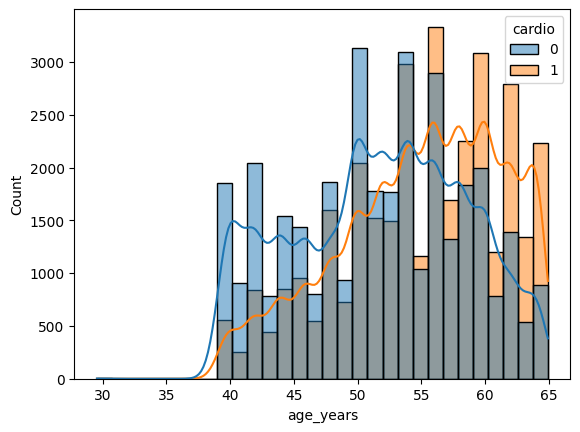

In [20]:
#Age distribution by cardio status
sns.histplot(data=df_clean, x='age_years', hue='cardio', bins=30, kde=True)
plt.show()

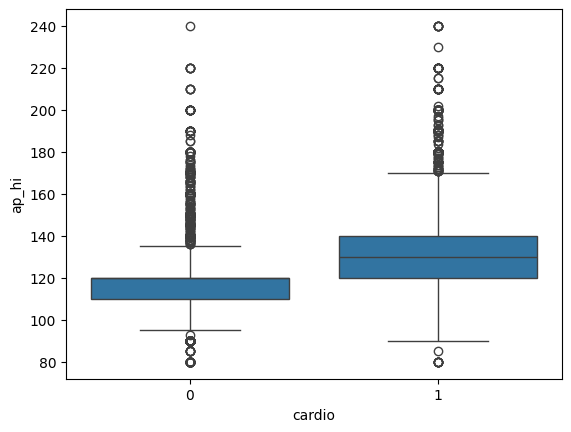

In [21]:
#Boxplot: systolic BP by cardio status
sns.boxplot(x='cardio', y='ap_hi', data=df_clean)
plt.show()


In [22]:
#Distribution of cholesterol levels
df_clean['cholesterol'].value_counts(normalize=True)

cholesterol
1    0.749829
2    0.135516
3    0.114656
Name: proportion, dtype: float64

In [23]:
#Percentage with above-normal glucose
(df_clean['gluc'] > 1).mean() * 100

np.float64(14.979650781147432)

In [24]:
#Insightful Analysis Questions 

In [25]:
#What percentage of the dataset has cardiovascular disease?
df['cardio'].value_counts(normalize=True) * 100


cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

In [26]:
#Is there a link between cholesterol and heart disease?
df.groupby('cholesterol')['cardio'].mean()


cholesterol
1    0.440107
2    0.602157
3    0.765435
Name: cardio, dtype: float64

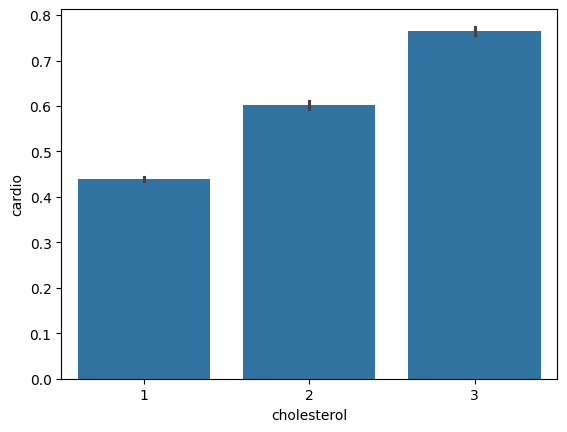

In [27]:
sns.barplot(x='cholesterol', y='cardio', data=df)
plt.show()

In [28]:
#Does age impact heart disease prevalence?
df['age_years'] = df['age'] / 365.25
df.groupby(pd.cut(df['age_years'], bins=10))['cardio'].mean()

C:\Users\hetal\AppData\Local\Temp\ipykernel_14672\3906843821.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['age_years'], bins=10))['cardio'].mean()


age_years
(29.528, 33.099]    0.000000
(33.099, 36.635]         NaN
(36.635, 40.171]    0.234138
(40.171, 43.707]    0.297639
(43.707, 47.243]    0.388320
(47.243, 50.779]    0.430041
(50.779, 54.315]    0.480830
(54.315, 57.851]    0.545354
(57.851, 61.387]    0.589741
(61.387, 64.923]    0.696026
Name: cardio, dtype: float64

In [29]:
#Is BMI higher in those with heart disease?
df['BMI'] = df['weight'] / ((df['height']/100)**2)
df.groupby('cardio')['BMI'].mean()

cardio
0    26.548175
1    28.566061
Name: BMI, dtype: float64

In [30]:
#Does physical activity reduce heart disease risk?
df.groupby('active')['cardio'].mean()

active
0    0.535774
1    0.490891
Name: cardio, dtype: float64

In [31]:
#Do smokers have more heart disease?
df.groupby('smoke')['cardio'].mean()

smoke
0    0.502107
1    0.474793
Name: cardio, dtype: float64

In [32]:
#Is systolic pressure significantly higher in those with heart disease?
df.groupby('cardio')['ap_hi'].mean()

cardio
0    120.432598
1    137.212042
Name: ap_hi, dtype: float64

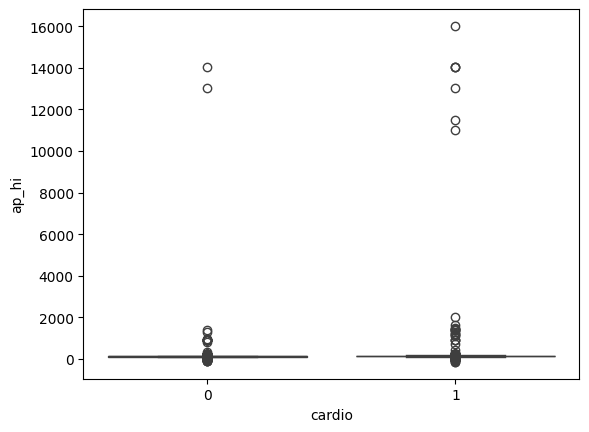

In [33]:
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.show()